In [133]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go
os.chdir("/Users/matheuspintoarratia/Desktop/quantumblack/deep-rl-mpc/")
from src.bounds import get_bounds_limits
warnings.filterwarnings("ignore")
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.style.use('seaborn-white')
cmap = cm.get_cmap('Spectral')

In [134]:
df = pd.read_csv("data/data_energy_train.csv")
bounds = get_bounds_limits(df, alpha=1)
bounds

  variable  lower_lim  upper_lim
0       at      1.810      37.11
1        v     25.360      81.56
2       ap   1000.990    1025.29
3       rh     41.505     100.16
4       pe    420.260     495.76


,variable,lower_lim,upper_lim
0,at,1.810,37.11
1,v,25.360,81.56
2,ap,1000.990,1025.29
3,rh,41.505,100.16
4,pe,420.260,495.76


In [135]:
df1 = pd.read_csv("./results/test_results/AC2.csv")
df2 = pd.read_csv("./results/test_results/PPO2.csv")
df3 = pd.read_csv("./results/test_results/DDPG.csv")
df4 = pd.read_csv("./results/test_results/TD3.csv")

df = pd.concat([df1, df2, df3, df4], axis=0)
df["mape"] = (df["real"] - df["prediction"]) / df["real"] * 100
df["mape"] = df["mape"].apply(abs)
#df.reset_index(drop=True, inplace=True)



In [136]:
df["model_name"].unique()

array(['AC2', 'PPO2', 'DDPG', 'TD3'], dtype=object)

In [137]:
target = "pe"
control_variables = ["at", "v"]

print("control_variables: ", control_variables)
print("target: ", target)


control_variables:  ['at', 'v']
target:  pe


In [138]:
df["mape"].mean()

4.38007352989963

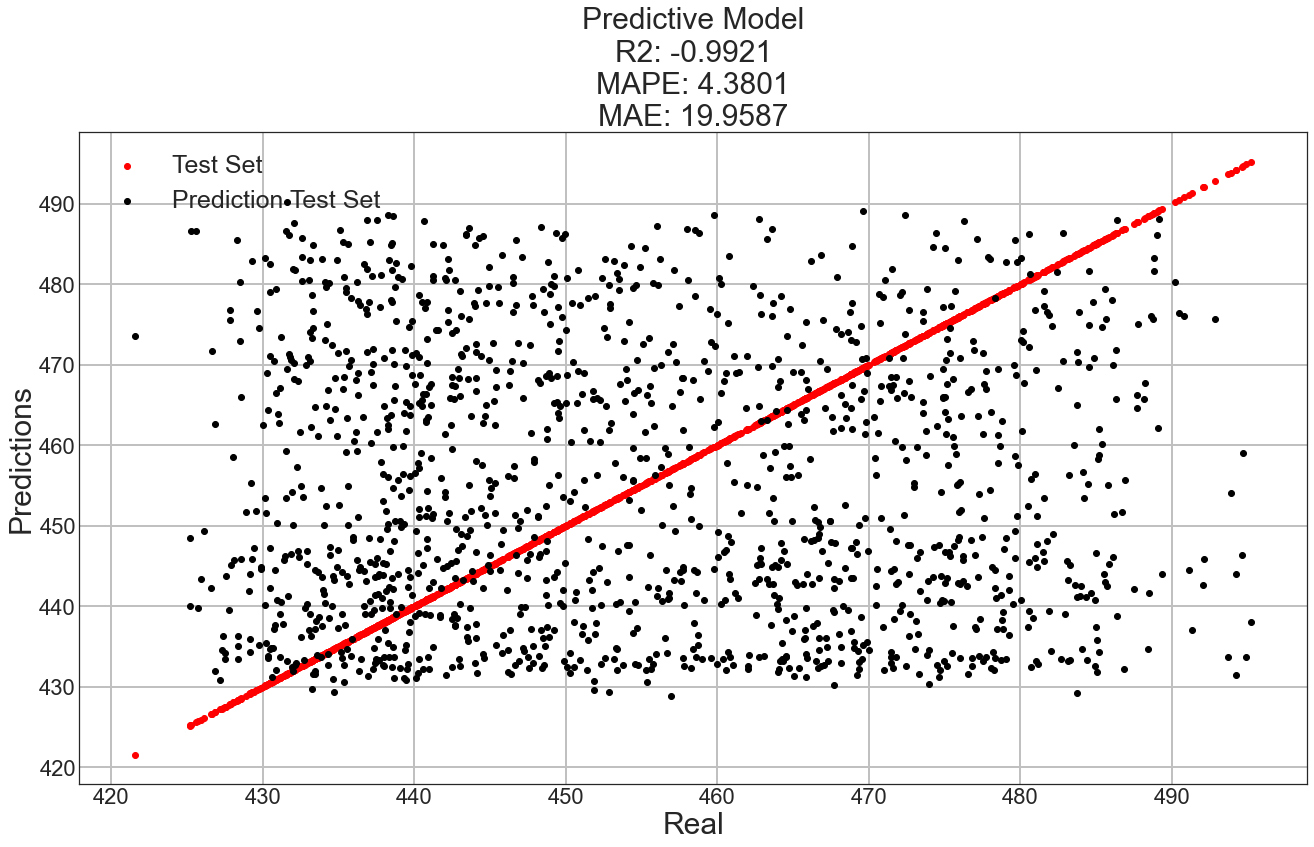

In [139]:
data = df[df["model_name"] == "PPO2"]
data.reset_index(drop=True, inplace=True)
y_pred = np.array(data["prediction"].values)
y_test = np.array(data["real"].values)

def plot_xy_results(y_pred, y_test, name="Regularized Regression"):
    y_pred = np.reshape(y_pred, (-1, 1)) 
    y_test = np.reshape(y_test, (-1, 1)) 
    letter_size = 20
    mae = np.abs(y_pred - y_test).mean()
    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    rmse = np.sqrt(mean_squared_error(y_pred, y_test))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    mae = str(round(mae, 4))
    mape = str(round(mape, 4))
    mse = str(round(mse, 4))
    rmse = str(round(rmse, 4))
    r2 = str(round(r2, 4))

    fig, ax = plt.subplots(1, figsize=(22, 12))
    plt.scatter(y_test, y_test, color='red')
    plt.scatter(y_test, y_pred, color='k')
    title = f"{name}" + "\n" + f"R2: {r2}" + "\n" + f"MAPE: {str(mape)}" + "\n" + f"MAE: {str(mae)}"
    plt.title(title, fontsize=30)
    plt.xlabel('Real', fontsize=30)
    plt.ylabel('Predictions', fontsize=30)
    plt.grid(color='silver', linestyle='-', linewidth=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(['Test Set', 'Prediction Test Set'], loc='upper left',
               prop={'size': letter_size+5})
    plt.show()

plot_xy_results(y_pred, y_test, name="Predictive Model")

In [140]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def get_metrics_performance(data):
    
    y_pred = np.array(data["prediction"].values)
    y_test = np.array(data["real"].values)
    y_pred = np.reshape(y_pred, (-1, 1)) 
    y_test = np.reshape(y_test, (-1, 1)) 
    mae = np.abs(y_pred - y_test).mean()
    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    rmse = np.sqrt(mean_squared_error(y_pred, y_test))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    mae = str(round(mae, 4))
    mape = str(round(mape, 4))
    mse = str(round(mse, 4))
    rmse = str(round(rmse, 4))
    r2 = str(round(r2, 4))
    bar = "=============================================================================================="
    title = bar + "\n" + "Model Metrics:" + "\n" + f"R2: {r2}" + "\n" + f"MAPE: {str(mape)}" + "\n" + f"MAE: {str(mae)}"
    return title

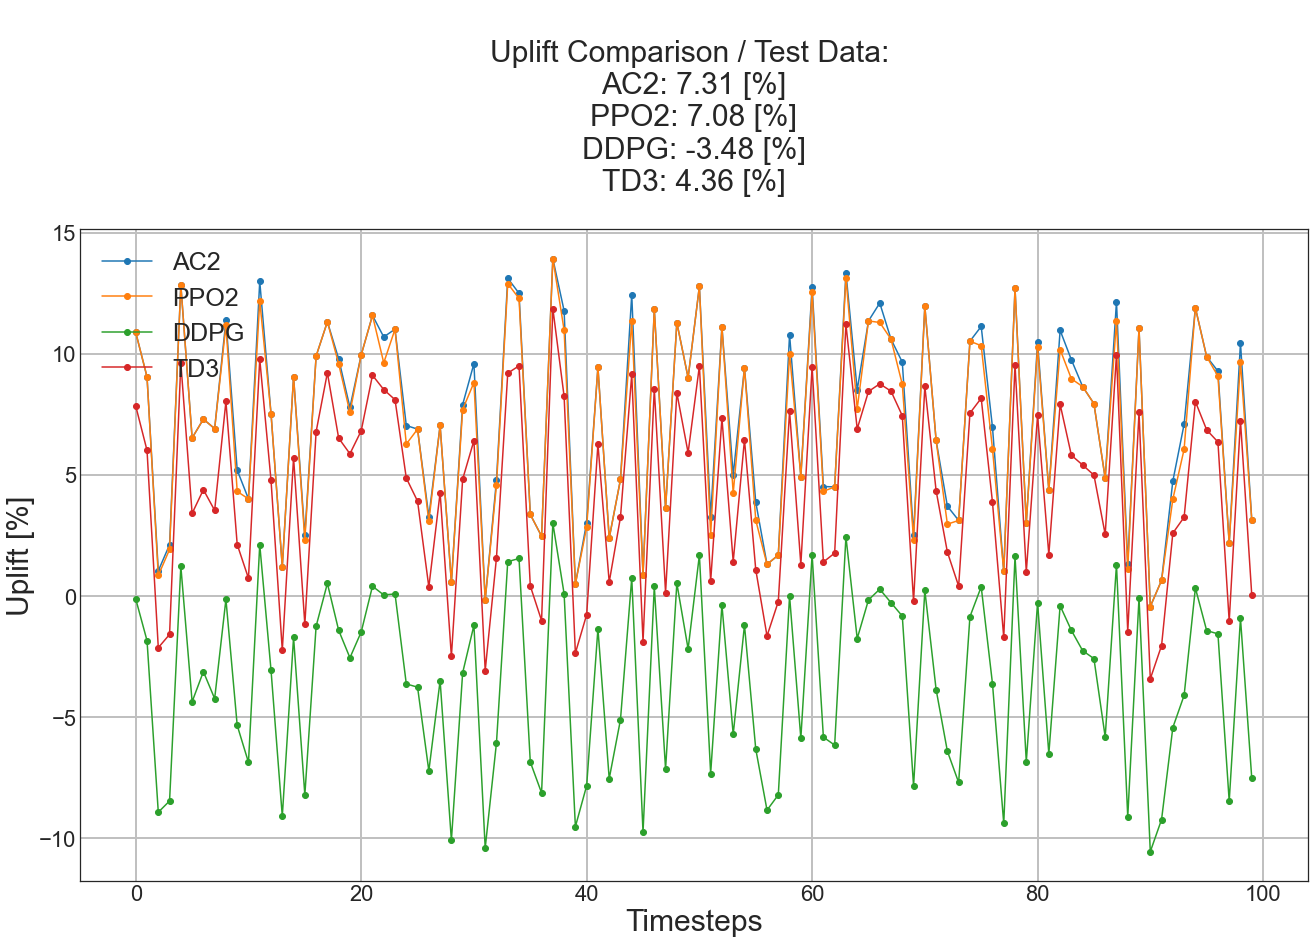

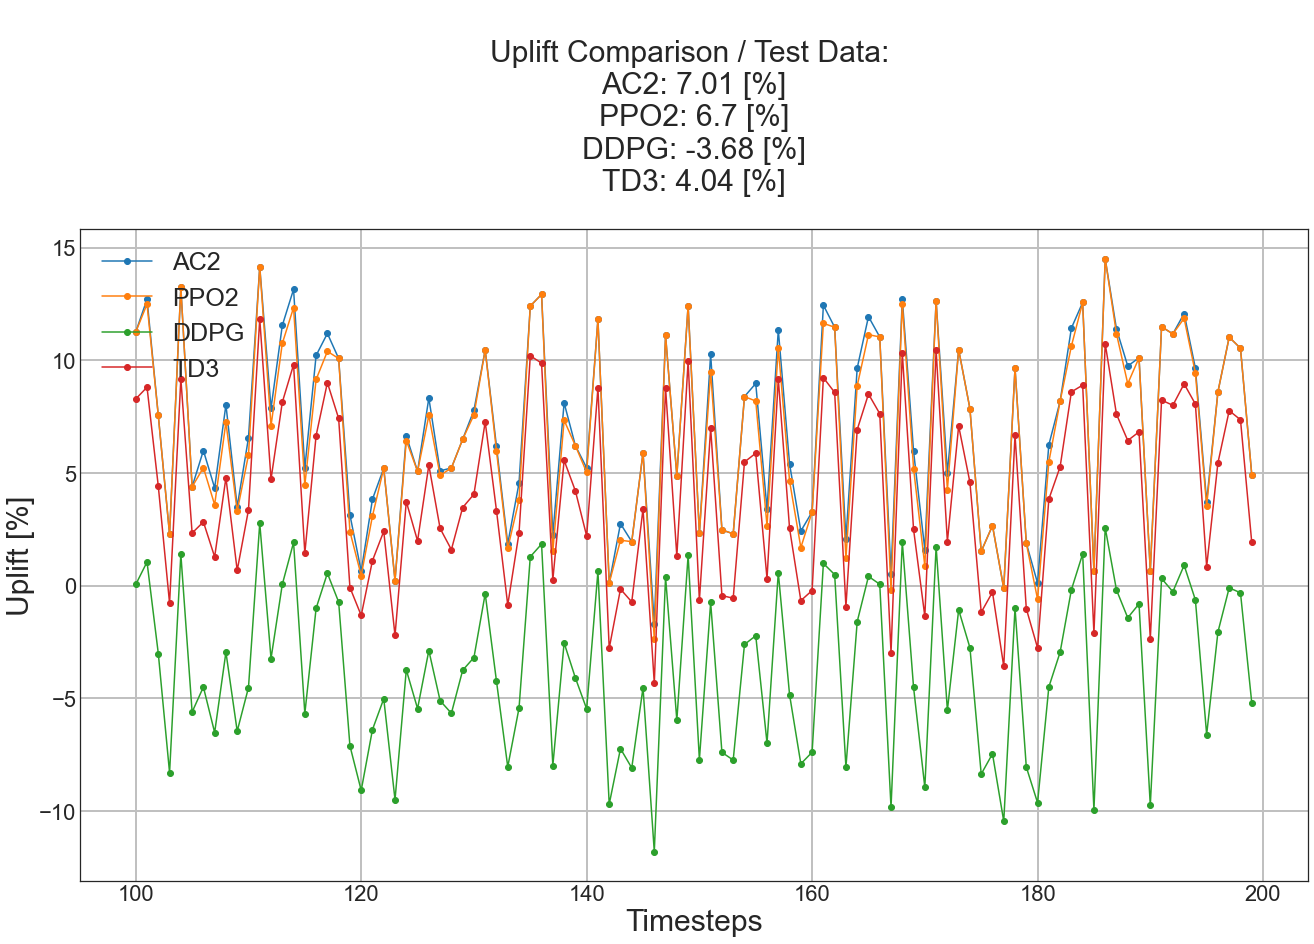

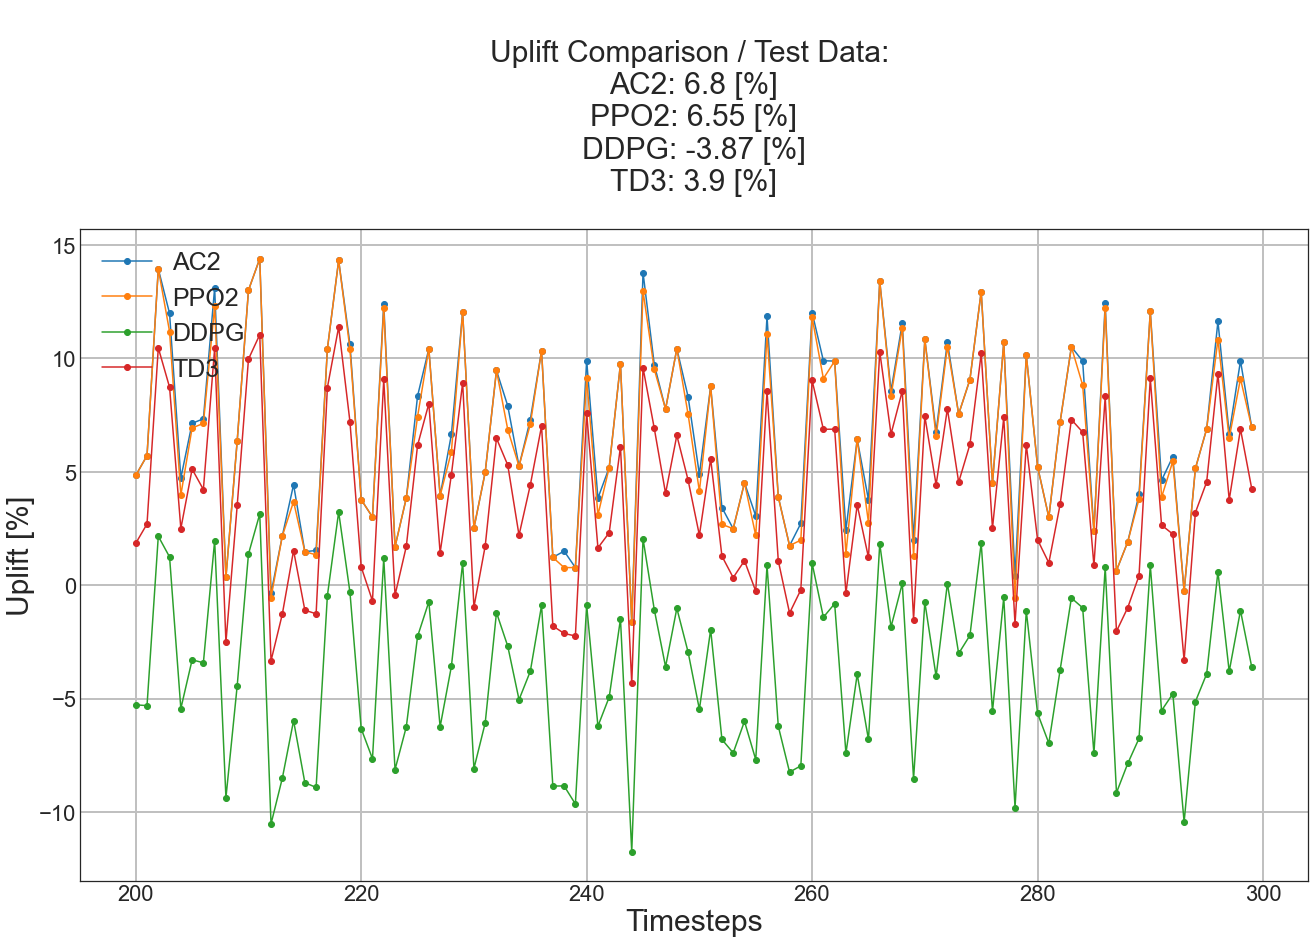

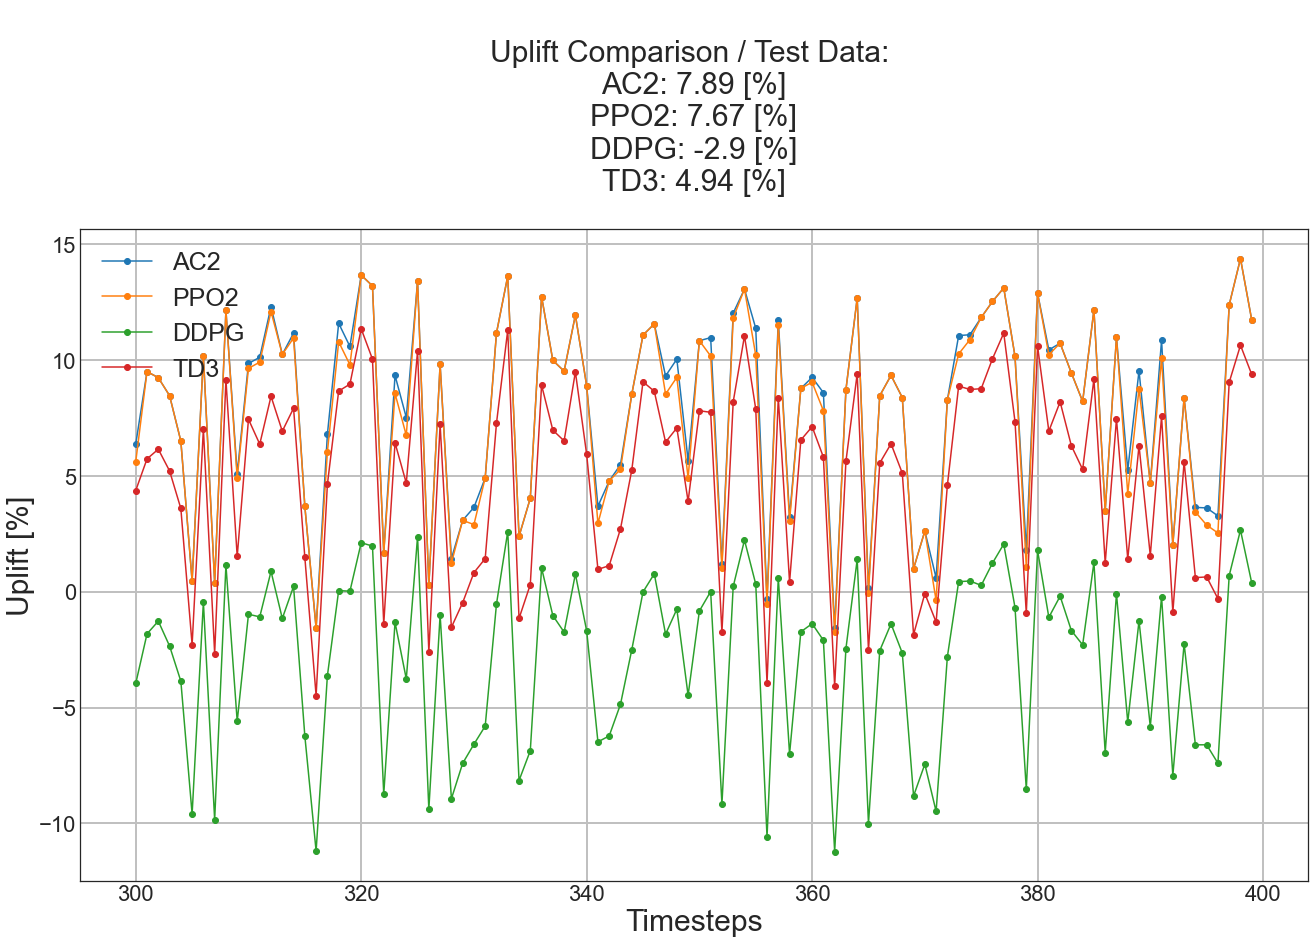

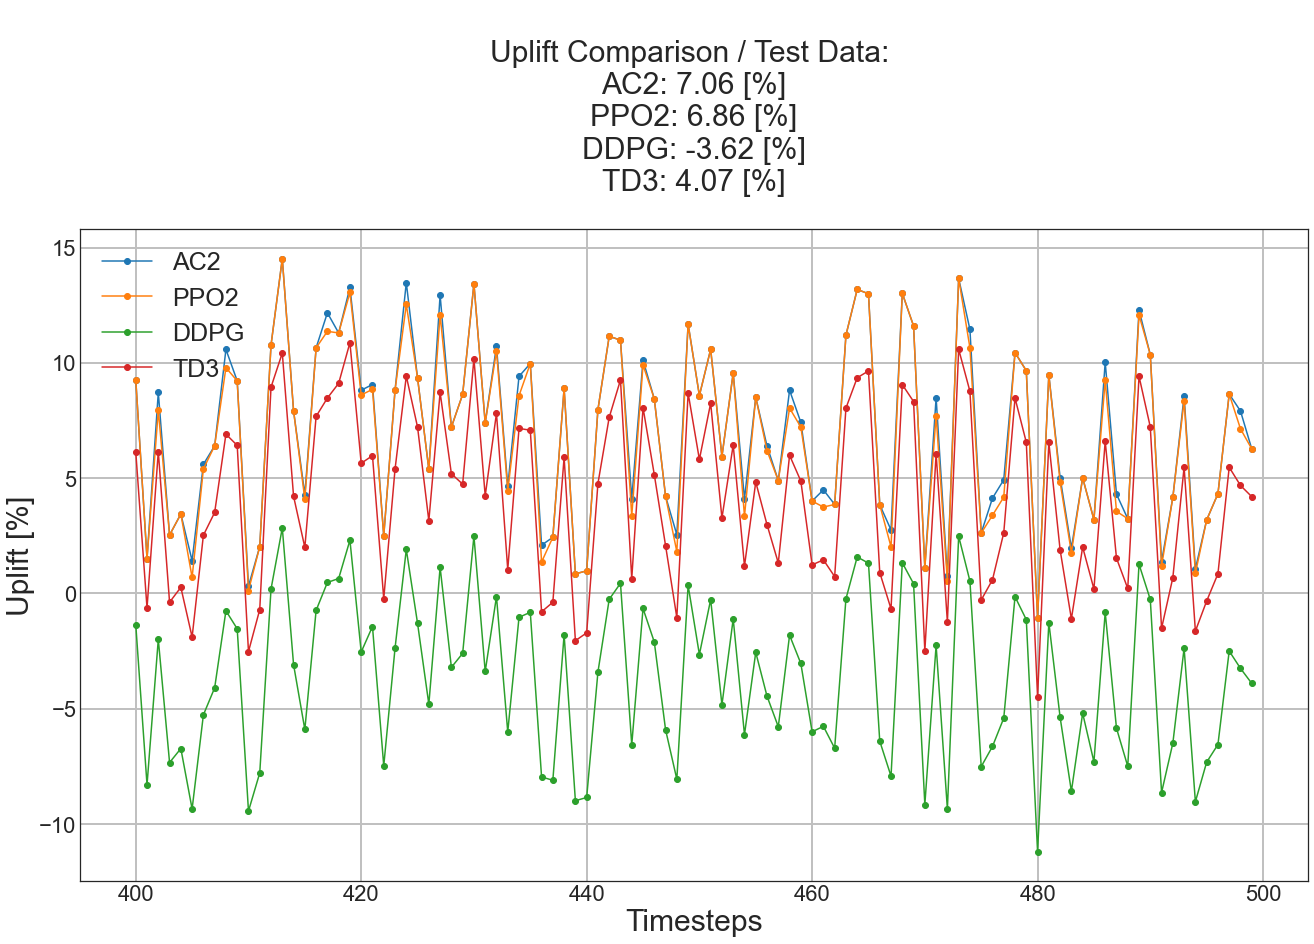

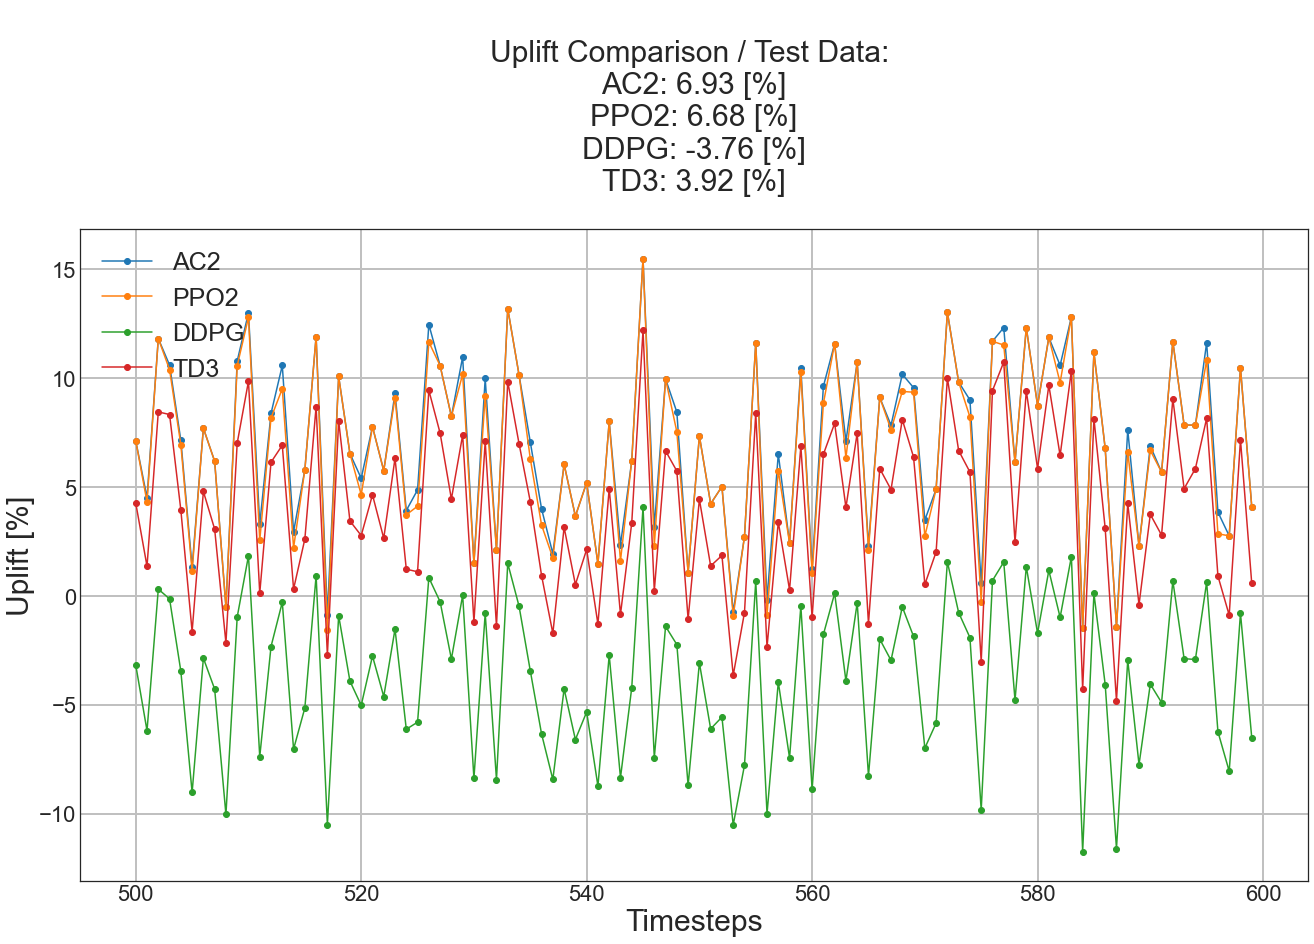

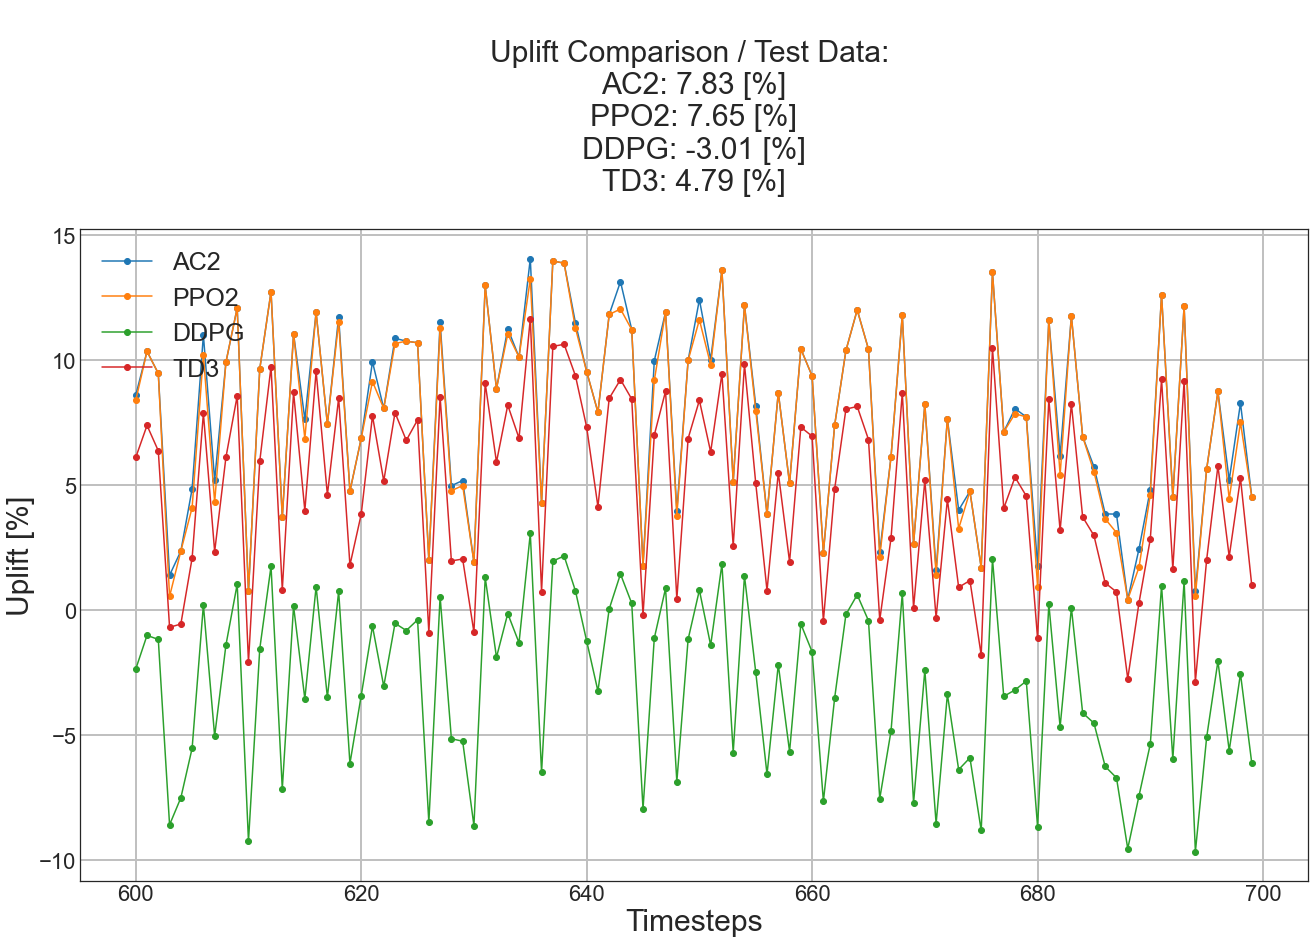

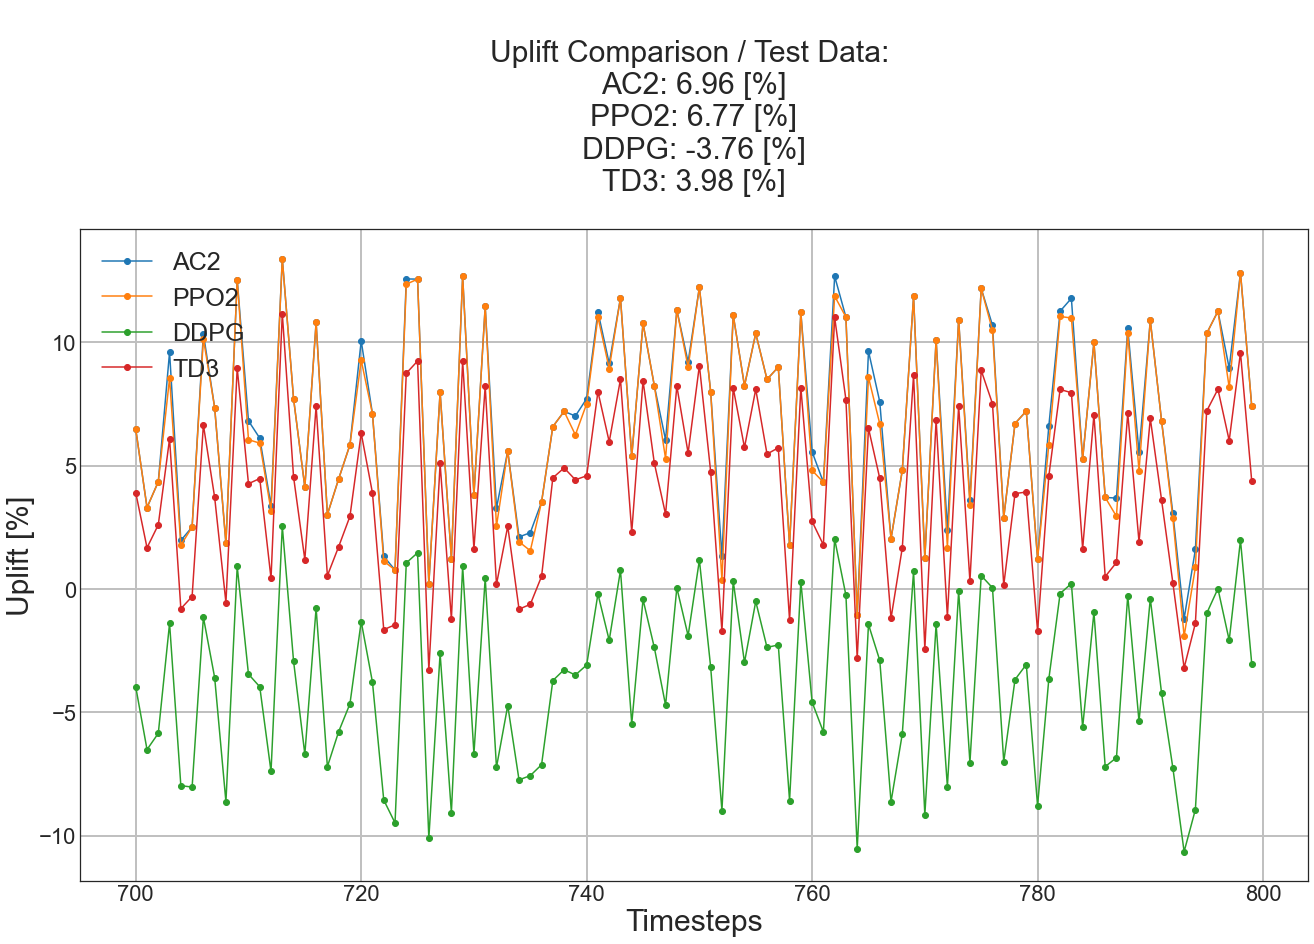

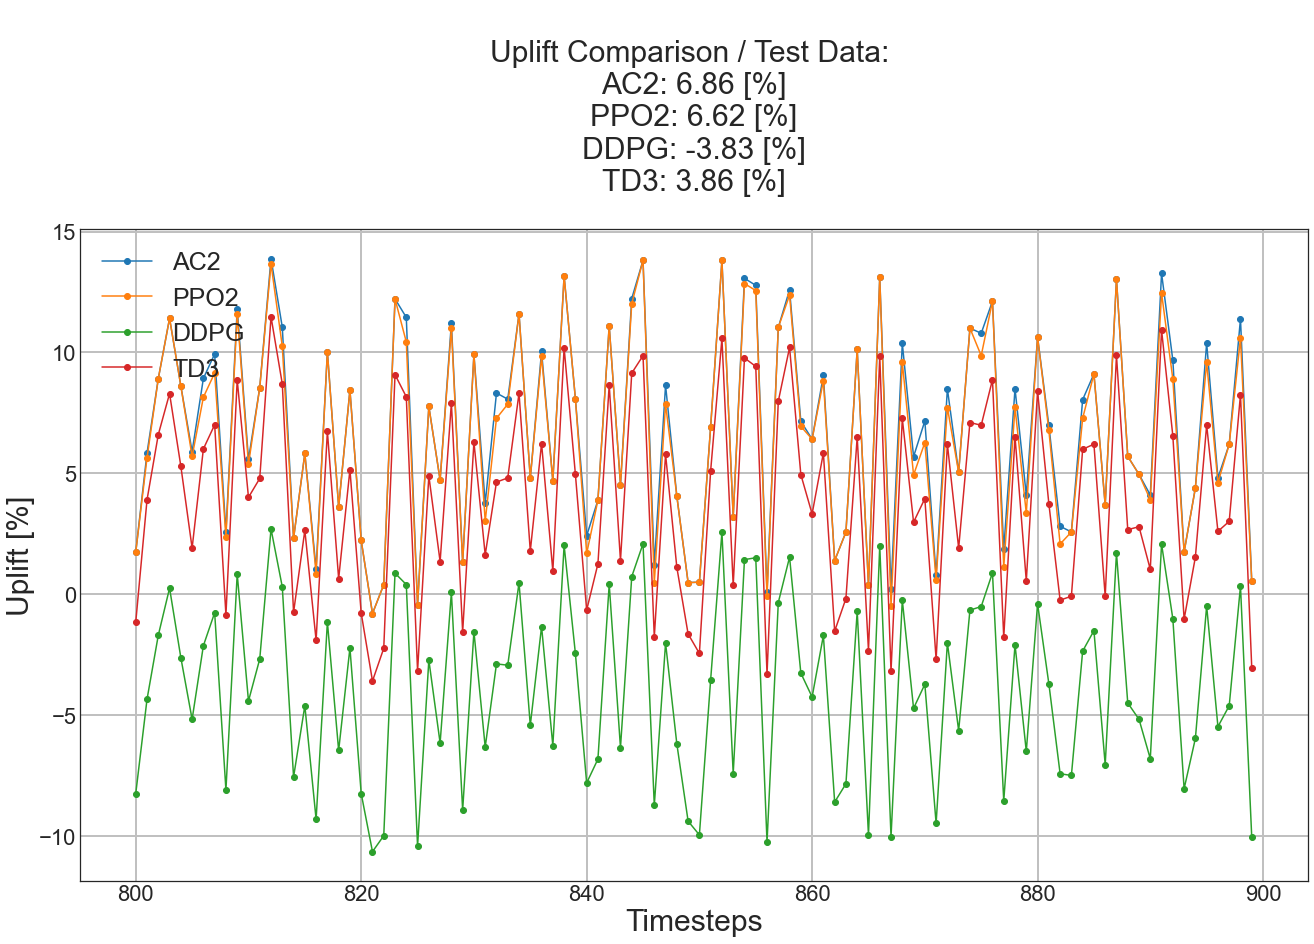

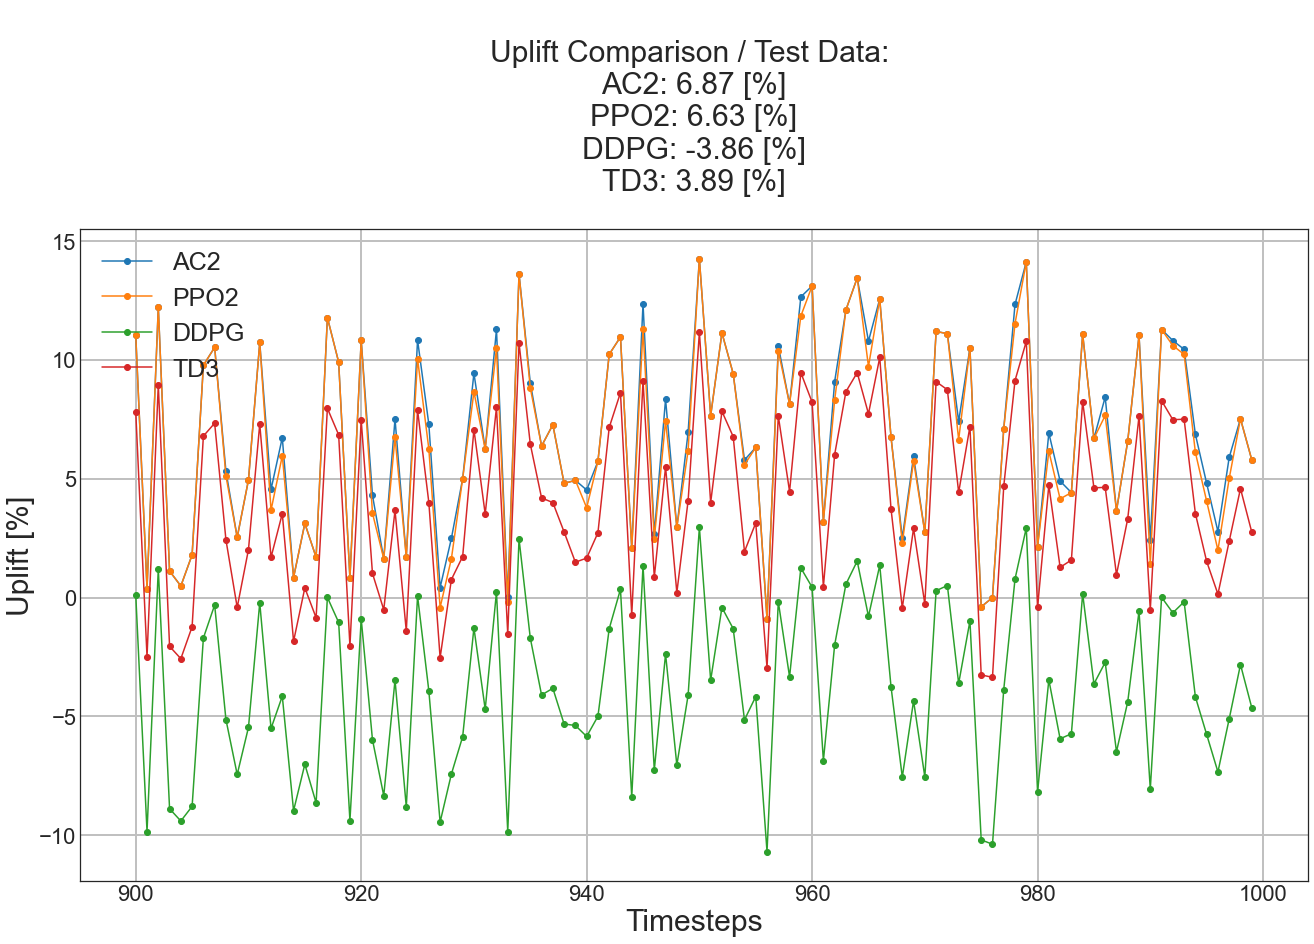

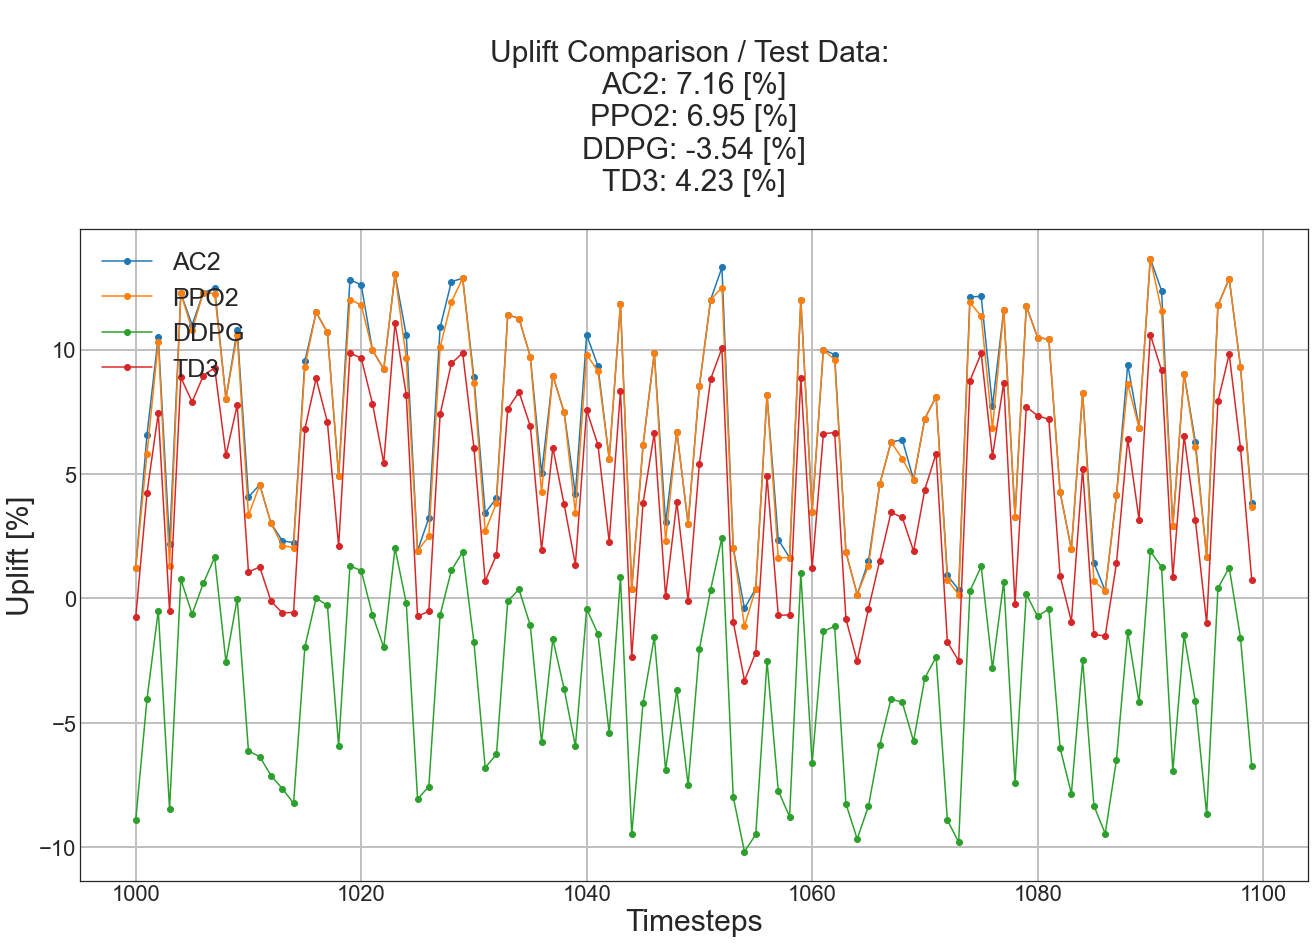

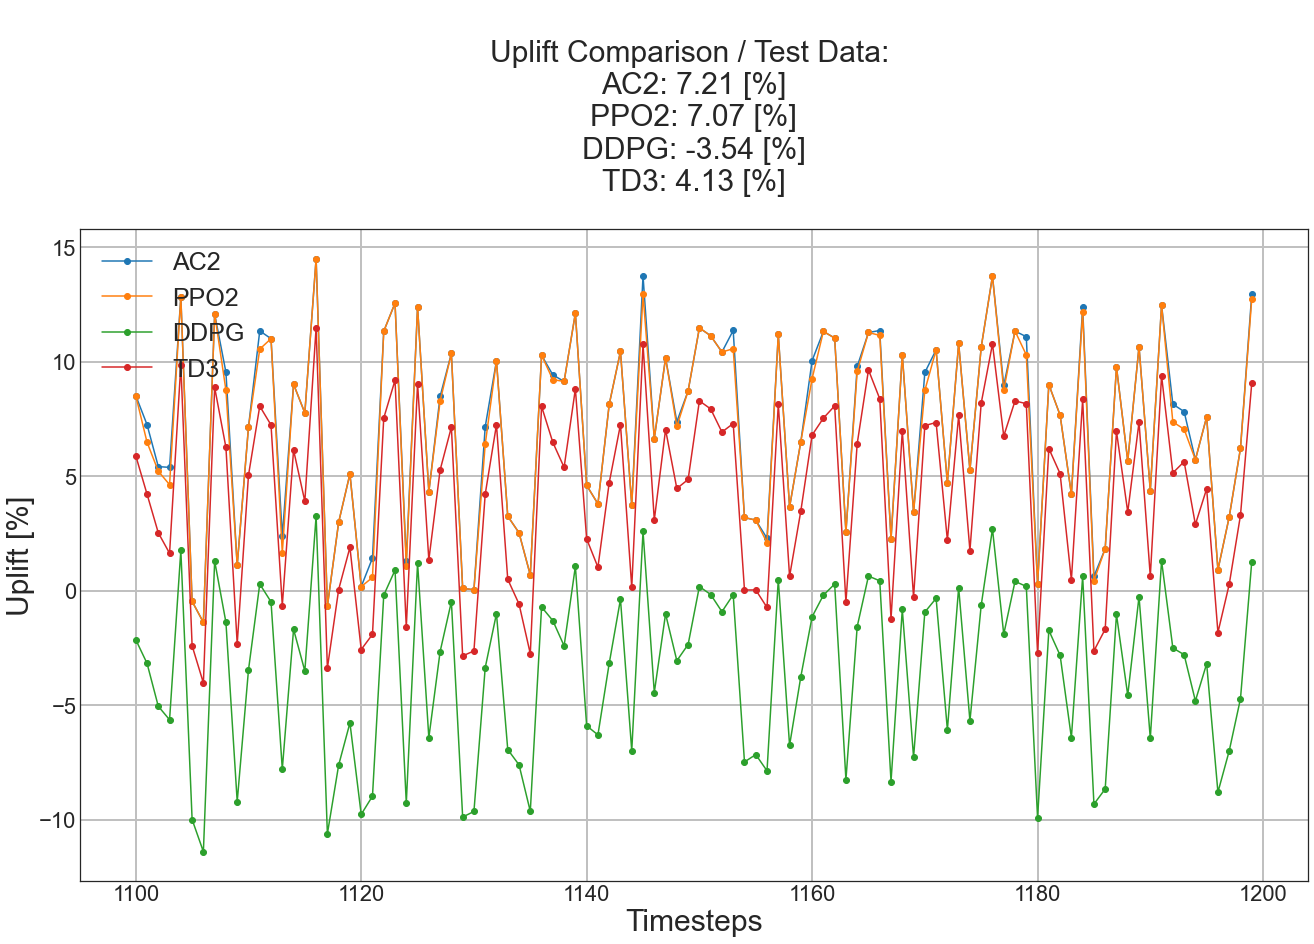

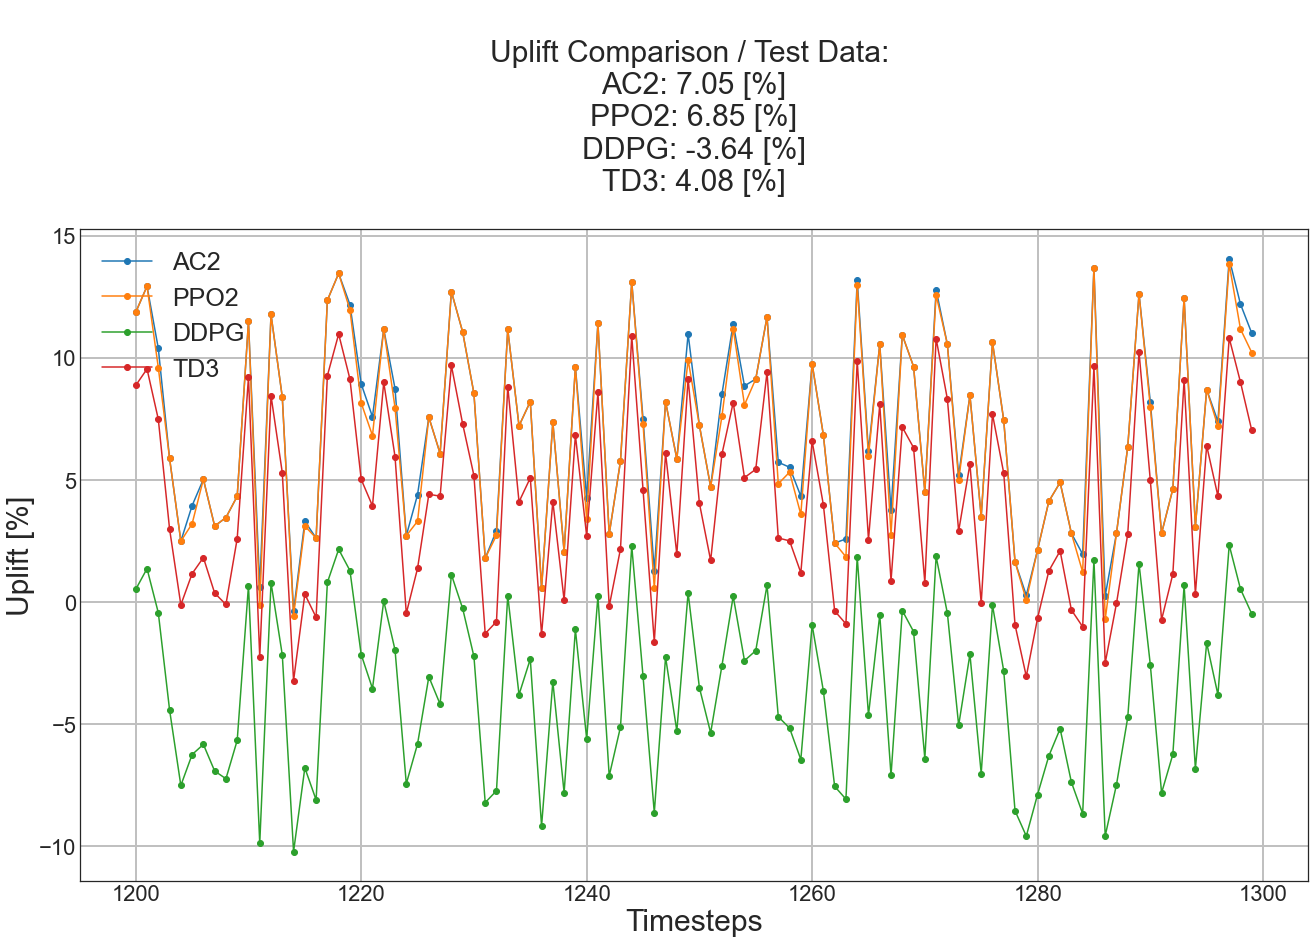

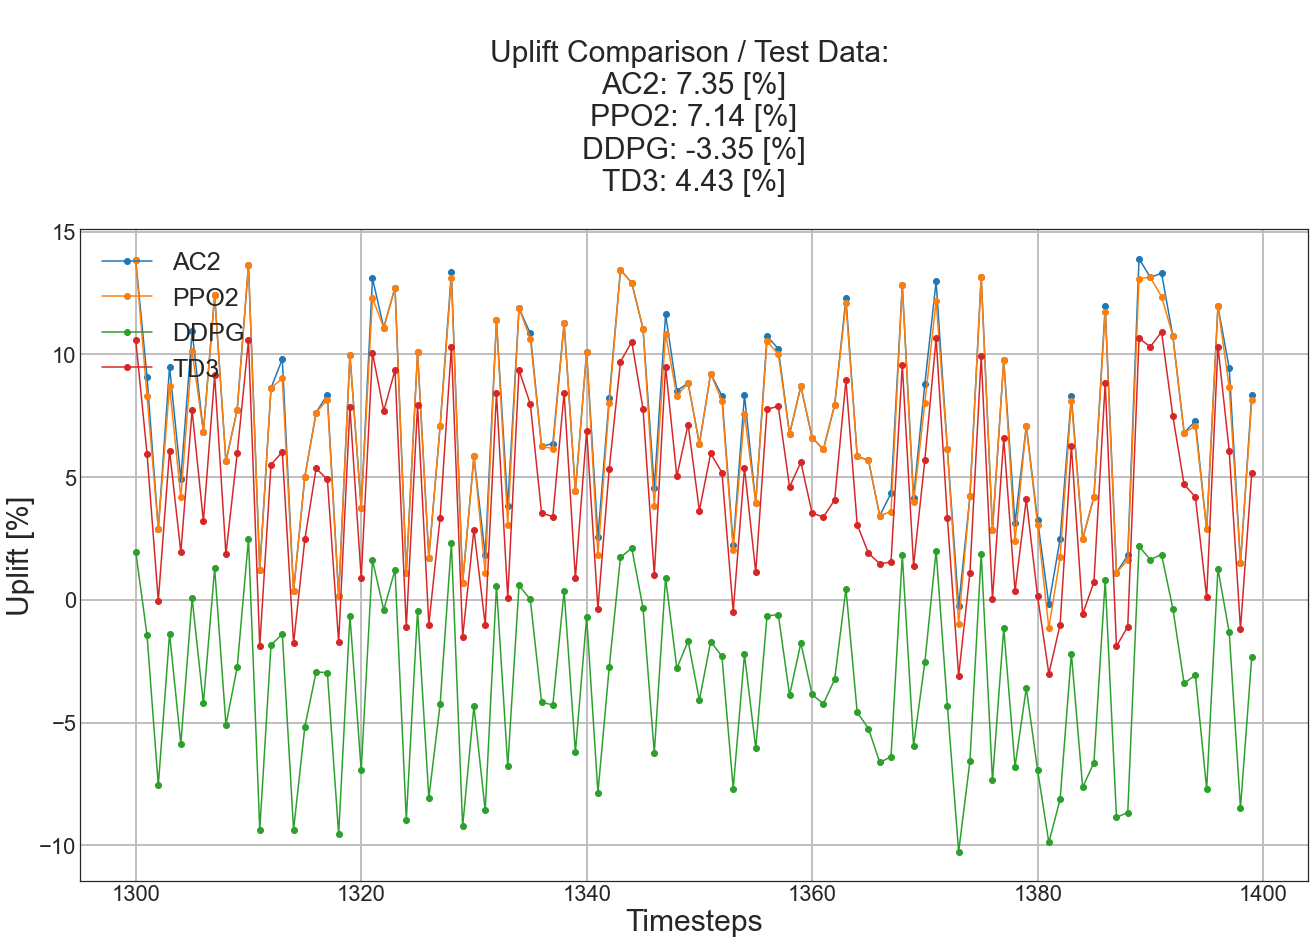

In [145]:

size = 100
categories = list(df["model_name"].unique())

metrics = get_metrics_performance(df[df["model_name"] == "AC2"])
metrics = ""
print(metrics)
for i in range(0, len(df1)-size, size):
    fig, ax = plt.subplots(1, figsize=(22, 12))
    title = "\n" + "Uplift Comparison / Test Data: " + "\n"
    legends = []
    for cat in categories:
        data = df[df["model_name"] == cat]
        data["uplift"].iloc[i: i + size].plot(marker="o")
        uplift = round(df[df["model_name"] == cat]["uplift"].iloc[i: i + size].mean(), 2)
        name = cat + ": " + str(uplift) + " [%]" + "\n"
        title += name
        legends.append(cat)
    title += metrics
    plt.title(title, fontsize=30)
    plt.xlabel('Timesteps', fontsize=30)
    plt.ylabel('Uplift [%]', fontsize=30)
    plt.grid(color='silver', linestyle='-', linewidth=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(legends, loc='upper left', prop={'size': 20+5})
    plt.show()

In [142]:
bounds

,variable,lower_lim,upper_lim
0,at,1.810,37.11
1,v,25.360,81.56
2,ap,1000.990,1025.29
3,rh,41.505,100.16
4,pe,420.260,495.76


In [143]:
df[df["model_name"] == "AC2"]

,rec_at,rec_v,at,v,ap,rh,rewards,optimized,prediction,real,uplift,model_name,mape
0,3.213872,25.36,22.19,48.78,1017.84,76.01,0.000000,486.89586,449.871580,439.14,10.874860,AC2,2.443772
1,3.384519,25.36,8.33,38.08,1018.94,73.78,8.563657,486.89586,480.948888,446.51,9.044783,AC2,7.712904
2,3.355875,25.36,10.73,44.92,1025.10,85.40,1.506212,486.89586,476.226411,481.89,1.038797,AC2,1.175287
3,3.210989,25.36,27.10,79.74,1005.43,86.05,2.431803,486.89586,433.624404,476.81,2.115279,AC2,9.057192
4,3.328254,25.36,19.44,39.53,1006.99,63.18,11.747029,486.89586,459.291972,431.51,12.835360,AC2,6.438315
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,3.318161,25.36,23.98,50.32,1008.41,67.75,8.820005,486.89586,444.796298,452.16,7.682205,AC2,1.628561
1432,3.346358,25.36,25.42,75.60,1017.39,77.63,9.113705,486.89586,437.403891,443.45,9.797240,AC2,1.363425
1433,3.206401,25.36,4.49,40.27,1012.01,76.50,11.739873,486.89586,488.540520,438.24,11.102560,AC2,11.477848
1434,3.669171,25.36,23.14,51.19,1009.56,77.20,-0.179567,486.89586,444.023606,494.24,-1.485946,AC2,10.160326


In [144]:

for model_name in df.model_name.unique():
    print(model_name)
    data = df[df["model_name"] == model_name]
    data.reset_index(drop=True, inplace=True)
    for control_variable in control_variables:
        rec_control_variable = "rec_" + control_variable
        lower_lim = bounds[bounds["variable"] == control_variable]["lower_lim"].values[0]
        upper_lim = bounds[bounds["variable"] == control_variable]["upper_lim"].values[0]
        print(control_variable, rec_control_variable)   

        fig = go.Figure(data=go.Parcoords(
            dimensions=list([
                dict(range=[lower_lim, upper_lim],
                    constraintrange=[0, 1],
                    label=control_variable,
                    values=data[control_variable]), 
                dict(range=[lower_lim, upper_lim],
                    label=rec_control_variable,
                    values=data[rec_control_variable]),
            ])
        )
        )
        fig.show()   

AC2
at rec_at


v rec_v


PPO2
at rec_at


v rec_v


DDPG
at rec_at


v rec_v


TD3
at rec_at


v rec_v
